In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
data=pd.read_csv(r'E:\Data Science Projects\Housing Prediction Krish Naik\data.csv')

In [3]:
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       501 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [5]:
data.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,501.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284341,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.705587,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.884000,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208000,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.625000,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [6]:
data.dropna(inplace=True)


In [7]:
data.shape

(501, 14)

In [8]:
data.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [9]:
data.corr()['MEDV']

CRIM      -0.390251
ZN         0.360031
INDUS     -0.486625
CHAS       0.174679
NOX       -0.428812
RM         0.696169
AGE       -0.375437
DIS        0.251709
RAD       -0.384730
TAX       -0.471253
PTRATIO   -0.511897
B          0.335387
LSTAT     -0.737720
MEDV       1.000000
Name: MEDV, dtype: float64

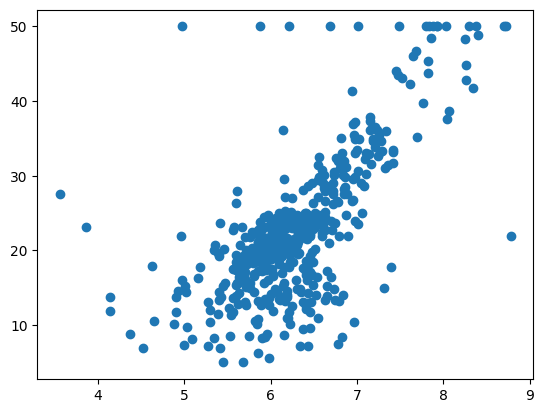

In [10]:
plt.scatter(data['RM'], data['MEDV'])

<Axes: xlabel='RM', ylabel='MEDV'>

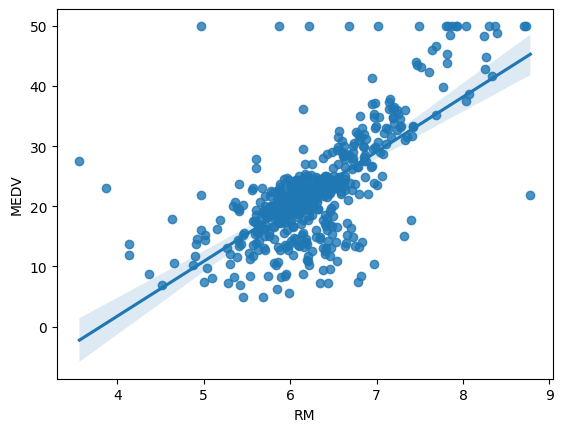

In [11]:
sns.regplot(x='RM',y='MEDV',data=data)

In [12]:
x=data.iloc[:,:-1]

In [13]:
y=data.iloc[:,-1]

In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [15]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [16]:
x_train=scaler.fit_transform(x_train)

In [17]:
x_test=scaler.transform(x_test)

In [18]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [19]:
regression.fit(x_train,y_train)

LinearRegression()

In [20]:
print(regression.coef_)

[-0.81333048  1.25793481  0.55901585  0.62921378 -1.90632294  2.57817719
  0.56191215 -2.87590127  2.74653476 -2.09048251 -2.03201533  1.20544035
 -4.54581734]


In [21]:
print(regression.intercept_)

22.840285714285717


In [22]:
reg_pred=regression.predict(x_test)

In [23]:
print(x_test.shape)

(151, 13)


In [24]:
reg_pred

array([11.18470187, 23.00563404, 15.50555989, 33.91377385, 22.85033375,
       11.52120718, 12.87909485, 19.68559436, 21.04526151, 11.33123451,
       18.86863905, 30.14960371, -1.11832542, 25.62332993,  2.86892345,
        8.03143995, 23.74581797, 18.48006615, 25.08802436, -6.69909852,
       13.05721404, 18.91286419, 27.07854376, 19.68268673, 22.34432239,
       16.60552708, 28.66835041, 26.17851266, 18.28698048, 20.9648065 ,
       20.99274995, 30.45869773, 17.88348023, 31.45467817, 31.04568544,
       21.85781507,  7.19466076, 23.35955087,  7.67299185, 25.28772941,
       13.06751099, 35.87850613, 14.55527766, 30.48366917, 12.54855213,
       28.33694316, 30.32808565, 19.98874661, 18.58460772, 13.49196425,
       23.92954047, 33.0591127 , 16.37371772, 11.0238909 , 34.65082608,
       33.84119359, 17.64417679, 18.519131  , 16.23822474, 27.42388838,
       20.31971468, 40.40623824, 20.22919151,  8.17914399, 25.84915232,
       27.38356934, 11.67432851,  7.40048488, 27.04285183, 16.64

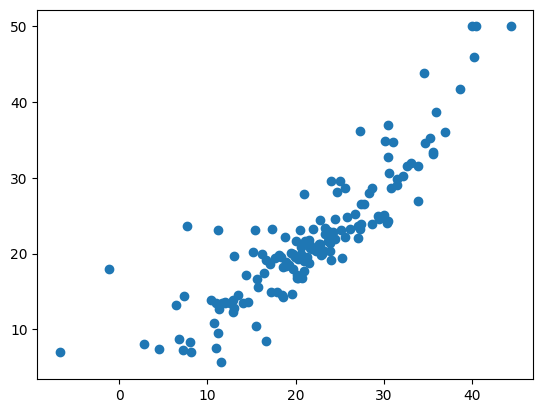

In [25]:
plt.scatter(reg_pred,y_test)

In [26]:
Residual=y_test-reg_pred

In [27]:
Residual

367    11.915298
76     -3.005634
380    -5.105560
160    -6.913774
108    -3.050334
         ...    
24     -0.109736
227    -1.048031
266     0.148491
435     1.444595
5       3.139275
Name: MEDV, Length: 151, dtype: float64

In [28]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
print (mean_absolute_error(y_test,reg_pred))
print (mean_squared_error(y_test,reg_pred))

3.054138762230471
18.380869507282043


In [29]:
from sklearn.metrics import r2_score
score=r2_score(y_test,reg_pred)
print(score)

0.7509342231409273


In [30]:
data_array=data.iloc[:, :-1].to_numpy()

In [31]:
data_array

array([[6.3200e-03, 1.8000e+01, 2.3100e+00, ..., 1.5300e+01, 3.9690e+02,
        4.9800e+00],
       [2.7310e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9690e+02,
        9.1400e+00],
       [2.7290e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9283e+02,
        4.0300e+00],
       ...,
       [6.0760e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
        5.6400e+00],
       [1.0959e-01, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9345e+02,
        6.4800e+00],
       [4.7410e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
        7.8800e+00]], shape=(501, 13))

In [32]:
data_array[0].reshape(1,-1)

array([[6.320e-03, 1.800e+01, 2.310e+00, 0.000e+00, 5.380e-01, 6.575e+00,
        6.520e+01, 4.090e+00, 1.000e+00, 2.960e+02, 1.530e+01, 3.969e+02,
        4.980e+00]])

In [33]:
data_first_row = pd.DataFrame([data.iloc[0].values], columns=data.columns)

In [34]:
data_first_row.shape

(1, 14)

In [35]:
data_first_row = data_first_row.iloc[:, :-1]

In [36]:
data_first_row.shape

(1, 13)

In [37]:
data_first_row_scaled = scaler.transform(data_first_row)

In [38]:
regression.predict(data_first_row_scaled)

array([30.32808565])

In [39]:
import pickle

In [40]:
pickle.dump(regression,open('regmodel.pkl','wb'))

In [41]:
pickled_model=pickle.load(open('regmodel.pkl','rb'))

In [42]:
pickled_model.predict(data_first_row_scaled)

array([30.32808565])